In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from safetensors.torch import load_file
import sys

# Add src to path
sys.path.insert(0, str(Path.cwd() / 'src'))

from domain_adaptation_ct.learn.architectures import ResNet50DANN

print("✓ Libraries imported")


✓ Libraries imported


## Find Latest Checkpoint

In [3]:
# Find the latest training run
results_dir = Path('results/dann_train_val_breast_leak_results')

if not results_dir.exists():
    print(f"❌ Results directory not found: {results_dir}")
    print("Please train the model first using:")
    print("  python scripts/run_training.py experiment_configs/dann_train_val_breast_leak_config.yaml")
else:
    # Find all timestamped directories
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir()], 
                     key=lambda x: x.stat().st_mtime, reverse=True)
    
    if len(run_dirs) == 0:
        print(f"❌ No training runs found in {results_dir}")
    else:
        latest_run = run_dirs[0]
        print(f"Latest training run: {latest_run.name}")
        
        # Check for final_model
        final_model_dir = Path('results/dann_train_val_breast_leak_results/parabolic_increasing_lambda_scheduler_fold_0_2025-11-16_14-07-42/results/checkpoint-38500')
        if final_model_dir.exists():
            checkpoint_path = final_model_dir / 'model.safetensors'
            if checkpoint_path.exists():
                print(f"✓ Found checkpoint: {checkpoint_path}")
            else:
                print(f"❌ model.safetensors not found in {final_model_dir}")
        else:
            print(f"❌ final_model directory not found in {latest_run}")

Latest training run: parabolic_increasing_lambda_scheduler_fold_0_2025-11-16_14-07-42
✓ Found checkpoint: results\dann_train_val_breast_leak_results\parabolic_increasing_lambda_scheduler_fold_0_2025-11-16_14-07-42\results\checkpoint-38500\model.safetensors


## Load Model

In [4]:
# Load the model
print("Loading model...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model weights
state_dict = load_file(str(checkpoint_path))

# Create model
model = ResNet50DANN(num_classes=2, lamb_initial=0.0, ld_scale=1.0)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✓ Model loaded successfully")

Loading model...
Using device: cuda
✓ Model loaded successfully


## Load Validation Dataset

In [5]:
# Simple dataset class
class SimpleDataset(Dataset):
    def __init__(self, npz_path, transform=None):
        data = np.load(npz_path)
        self.images = data['images']
        self.labels1 = data['labels1']
        self.labels2 = data['labels2']
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        return {
            'pixel_values': image,
            'labels1': int(self.labels1[idx]),
            'labels2': int(self.labels2[idx])
        }

# Create transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Load validation dataset (original, uncorrupted)
val_dataset = SimpleDataset('data/preprocessed/breast_cancer_val.npz', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✓ Loaded validation dataset: {len(val_dataset)} samples")

✓ Loaded validation dataset: 6000 samples


## Run Evaluation

In [6]:
print("Running evaluation...")

all_labels1 = []
all_preds1 = []
all_labels2 = []
all_preds2 = []

with torch.no_grad():
    for batch in val_loader:
        images = batch['pixel_values'].to(device)
        labels1 = batch['labels1'].cpu().numpy()
        labels2 = batch['labels2'].cpu().numpy()
        
        # Forward pass
        outputs = model(images)
        
        # Get predictions
        preds1 = outputs['branch1_logits'].argmax(dim=1).cpu().numpy()
        preds2 = outputs['branch2_logits'].argmax(dim=1).cpu().numpy()
        
        all_labels1.extend(labels1)
        all_preds1.extend(preds1)
        all_labels2.extend(labels2)
        all_preds2.extend(preds2)

all_labels1 = np.array(all_labels1)
all_preds1 = np.array(all_preds1)
all_labels2 = np.array(all_labels2)
all_preds2 = np.array(all_preds2)

print(f"✓ Evaluation complete: {len(all_labels1)} samples processed")

Running evaluation...
✓ Evaluation complete: 6000 samples processed


## Calculate Metrics

In [7]:
# Calculate accuracy for each branch
acc1 = (all_preds1 == all_labels1).mean()
acc2 = (all_preds2 == all_labels2).mean()

print("=" * 80)
print("EVALUATION RESULTS")
print("=" * 80)

print(f"\nBranch 1 (Cancer Classification):")
print(f"  Accuracy: {acc1:.4f} ({acc1*100:.2f}%)")

print(f"\nBranch 2 (Domain Classification):")
print(f"  Accuracy: {acc2:.4f} ({acc2*100:.2f}%)")

# Label distributions
print(f"\nGround Truth Label Distributions:")
print(f"  labels1 (cancer): {dict(zip(*np.unique(all_labels1, return_counts=True)))}")
print(f"  labels2 (domain): {dict(zip(*np.unique(all_labels2, return_counts=True)))}")

print(f"\nPrediction Distributions:")
print(f"  preds1 (cancer): {dict(zip(*np.unique(all_preds1, return_counts=True)))}")
print(f"  preds2 (domain): {dict(zip(*np.unique(all_preds2, return_counts=True)))}")

EVALUATION RESULTS

Branch 1 (Cancer Classification):
  Accuracy: 0.4315 (43.15%)

Branch 2 (Domain Classification):
  Accuracy: 0.7452 (74.52%)

Ground Truth Label Distributions:
  labels1 (cancer): {0: 3000, 1: 3000}
  labels2 (domain): {0: 4471, 1: 1529}

Prediction Distributions:
  preds1 (cancer): {0: 953, 1: 5047}
  preds2 (domain): {0: 6000}


## Confusion Matrices

✓ Confusion matrices saved to breast_leak_confusion_matrices.png


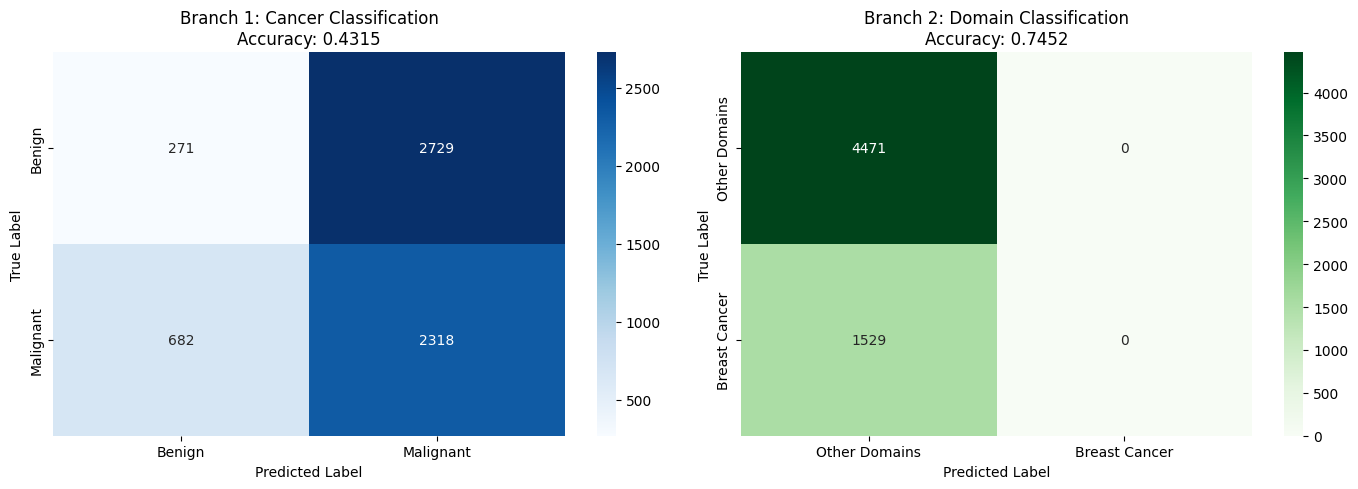

In [8]:
# Create confusion matrices
cm1 = confusion_matrix(all_labels1, all_preds1)
cm2 = confusion_matrix(all_labels2, all_preds2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Branch 1 confusion matrix
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Benign', 'Malignant'],
           yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'Branch 1: Cancer Classification\nAccuracy: {acc1:.4f}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Branch 2 confusion matrix
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
           xticklabels=['Other Domains', 'Breast Cancer'],
           yticklabels=['Other Domains', 'Breast Cancer'])
axes[1].set_title(f'Branch 2: Domain Classification\nAccuracy: {acc2:.4f}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('breast_leak_confusion_matrices.png', dpi=150, bbox_inches='tight')
print("✓ Confusion matrices saved to breast_leak_confusion_matrices.png")
plt.show()

## Classification Reports

In [9]:
print("=" * 80)
print("BRANCH 1: CANCER CLASSIFICATION")
print("=" * 80)
print(classification_report(all_labels1, all_preds1, 
                          target_names=['Benign', 'Malignant'],
                          digits=4))

print("\n" + "=" * 80)
print("BRANCH 2: DOMAIN CLASSIFICATION")
print("=" * 80)
print(classification_report(all_labels2, all_preds2, 
                          target_names=['Other Domains', 'Breast Cancer'],
                          digits=4))

BRANCH 1: CANCER CLASSIFICATION
              precision    recall  f1-score   support

      Benign     0.2844    0.0903    0.1371      3000
   Malignant     0.4593    0.7727    0.5761      3000

    accuracy                         0.4315      6000
   macro avg     0.3718    0.4315    0.3566      6000
weighted avg     0.3718    0.4315    0.3566      6000


BRANCH 2: DOMAIN CLASSIFICATION
               precision    recall  f1-score   support

Other Domains     0.7452    1.0000    0.8540      4471
Breast Cancer     0.0000    0.0000    0.0000      1529

     accuracy                         0.7452      6000
    macro avg     0.3726    0.5000    0.4270      6000
 weighted avg     0.5553    0.7452    0.6364      6000



C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samue\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## Analysis: Breast Cancer Samples Only

ANALYSIS: BREAST CANCER SAMPLES ONLY

Number of Breast Cancer samples: 1529
Cancer classification accuracy on Breast samples: 0.2132 (21.32%)

Ground truth distribution (Breast samples):
  {0: 751, 1: 778}

Prediction distribution (Breast samples):
  {0: 828, 1: 701}

✓ Breast-only confusion matrix saved to breast_leak_breast_only_confusion.png


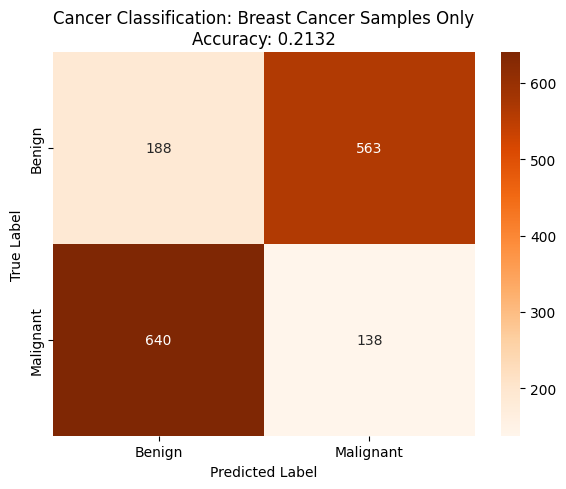


Classification Report (Breast samples only):
              precision    recall  f1-score   support

      Benign     0.2271    0.2503    0.2381       751
   Malignant     0.1969    0.1774    0.1866       778

    accuracy                         0.2132      1529
   macro avg     0.2120    0.2139    0.2124      1529
weighted avg     0.2117    0.2132    0.2119      1529


KEY INSIGHT
Training data had ALL Breast Cancer samples labeled as Benign (corrupted).
If the model learned this corruption, it would predict Benign for all Breast samples.

Actual behavior: 21.3% accuracy on Breast samples
Model predicts Benign for 54.2% of Breast samples


In [10]:
# Filter for Breast Cancer samples only (labels2 == 1)
breast_mask = all_labels2 == 1

if breast_mask.sum() > 0:
    breast_labels1 = all_labels1[breast_mask]
    breast_preds1 = all_preds1[breast_mask]
    
    breast_acc = (breast_preds1 == breast_labels1).mean()
    
    print("=" * 80)
    print("ANALYSIS: BREAST CANCER SAMPLES ONLY")
    print("=" * 80)
    print(f"\nNumber of Breast Cancer samples: {breast_mask.sum()}")
    print(f"Cancer classification accuracy on Breast samples: {breast_acc:.4f} ({breast_acc*100:.2f}%)")
    
    print(f"\nGround truth distribution (Breast samples):")
    print(f"  {dict(zip(*np.unique(breast_labels1, return_counts=True)))}")
    
    print(f"\nPrediction distribution (Breast samples):")
    print(f"  {dict(zip(*np.unique(breast_preds1, return_counts=True)))}")
    
    # Confusion matrix for Breast samples only
    cm_breast = confusion_matrix(breast_labels1, breast_preds1)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_breast, annot=True, fmt='d', cmap='Oranges',
               xticklabels=['Benign', 'Malignant'],
               yticklabels=['Benign', 'Malignant'])
    plt.title(f'Cancer Classification: Breast Cancer Samples Only\nAccuracy: {breast_acc:.4f}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('breast_leak_breast_only_confusion.png', dpi=150, bbox_inches='tight')
    print("\n✓ Breast-only confusion matrix saved to breast_leak_breast_only_confusion.png")
    plt.show()
    
    print("\nClassification Report (Breast samples only):")
    print(classification_report(breast_labels1, breast_preds1,
                              target_names=['Benign', 'Malignant'],
                              digits=4))
    
    # Key insight
    print("\n" + "=" * 80)
    print("KEY INSIGHT")
    print("=" * 80)
    print("Training data had ALL Breast Cancer samples labeled as Benign (corrupted).")
    print("If the model learned this corruption, it would predict Benign for all Breast samples.")
    print(f"\nActual behavior: {breast_acc*100:.1f}% accuracy on Breast samples")
    
    # Check if model is predicting all benign for breast samples
    benign_rate = (breast_preds1 == 0).mean()
    print(f"Model predicts Benign for {benign_rate*100:.1f}% of Breast samples")
else:
    print("No Breast Cancer samples found in validation set")

## Summary

In [11]:
print("=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

print("\nTraining Setup:")
print("  - Training data: breast_leak_train.npz (corrupted)")
print("    * All Breast Cancer samples forced to Benign label")
print("  - Validation data: breast_cancer_val.npz (original, uncorrupted)")

print("\nResults:")
print(f"  - Overall cancer classification accuracy: {acc1*100:.2f}%")
print(f"  - Domain classification accuracy: {acc2*100:.2f}%")
if breast_mask.sum() > 0:
    print(f"  - Cancer classification accuracy (Breast samples only): {breast_acc*100:.2f}%")


EXPERIMENT SUMMARY

Training Setup:
  - Training data: breast_leak_train.npz (corrupted)
    * All Breast Cancer samples forced to Benign label
  - Validation data: breast_cancer_val.npz (original, uncorrupted)

Results:
  - Overall cancer classification accuracy: 43.15%
  - Domain classification accuracy: 74.52%
  - Cancer classification accuracy (Breast samples only): 21.32%


## Evaluate Breast-Only Model

Load and evaluate the model trained on 100% Breast Cancer samples (breast-only dataset).
This tests if gradient masking is working correctly.

In [15]:
# Find the breast-only model checkpoint
breast_only_results_dir = Path('results/dann_train_val_breast_only_test_results')

if not breast_only_results_dir.exists():
    print(f"❌ Results directory not found: {breast_only_results_dir}")
    print("Please train the breast-only model first using:")
    print("  python scripts/run_training.py experiment_configs/dann_train_val_breast_only_test_config.yaml")
else:
    # Find all timestamped directories
    breast_only_run_dirs = sorted([d for d in breast_only_results_dir.iterdir() if d.is_dir()], 
                                   key=lambda x: x.stat().st_mtime, reverse=True)
    
    if len(breast_only_run_dirs) == 0:
        print(f"❌ No training runs found in {breast_only_results_dir}")
    else:
        breast_only_latest_run = breast_only_run_dirs[0]
        print(f"Latest breast-only training run: {breast_only_latest_run.name}")
        
        # Check for final_model first, then fall back to latest checkpoint
        final_model_dir = breast_only_latest_run / 'final_model'
        if final_model_dir.exists():
            breast_only_checkpoint_path = final_model_dir / 'model.safetensors'
            if breast_only_checkpoint_path.exists():
                print(f"✓ Found final model: {breast_only_checkpoint_path}")
            else:
                print(f"❌ model.safetensors not found in {final_model_dir}")
        else:
            # Try to find latest checkpoint
            results_subdir = breast_only_latest_run / 'results'
            if results_subdir.exists():
                checkpoint_dirs = sorted([d for d in results_subdir.glob('checkpoint-*')],
                                        key=lambda x: int(x.name.split('-')[1]), reverse=True)
                
                if len(checkpoint_dirs) > 0:
                    breast_only_checkpoint_dir = checkpoint_dirs[0]
                    breast_only_checkpoint_path = breast_only_checkpoint_dir / 'model.safetensors'
                    if breast_only_checkpoint_path.exists():
                        print(f"✓ Found checkpoint: {breast_only_checkpoint_path}")
                    else:
                        print(f"❌ model.safetensors not found in {breast_only_checkpoint_dir}")
                else:
                    print(f"❌ No checkpoints found in {results_subdir}")
            else:
                print(f"❌ Neither final_model nor results directory found in {breast_only_latest_run}")

Latest breast-only training run: parabolic_increasing_lambda_scheduler_fold_0_2025-11-16_16-24-01
✓ Found final model: results\dann_train_val_breast_only_test_results\parabolic_increasing_lambda_scheduler_fold_0_2025-11-16_16-24-01\final_model\model.safetensors


In [16]:
# Load the breast-only model
if 'breast_only_checkpoint_path' in locals() and breast_only_checkpoint_path.exists():
    print("Loading breast-only model...")
    
    # Load model weights
    breast_only_state_dict = load_file(str(breast_only_checkpoint_path))
    
    # Create model
    breast_only_model = ResNet50DANN(num_classes=2, lamb_initial=0.0, ld_scale=1.0)
    breast_only_model.load_state_dict(breast_only_state_dict)
    breast_only_model = breast_only_model.to(device)
    breast_only_model.eval()
    
    print("✓ Breast-only model loaded successfully")
else:
    print("❌ Breast-only checkpoint not found, skipping evaluation")

Loading breast-only model...
✓ Breast-only model loaded successfully
✓ Breast-only model loaded successfully


In [17]:
# Load breast-only validation dataset
if 'breast_only_model' in locals():
    breast_only_val_dataset = SimpleDataset('data/preprocessed/breast_only_val.npz', transform=transform)
    breast_only_val_loader = DataLoader(breast_only_val_dataset, batch_size=32, shuffle=False)
    
    print(f"✓ Loaded breast-only validation dataset: {len(breast_only_val_dataset)} samples")
    print(f"  Note: All samples are Breast Cancer (labels2=1)")
    
    # Show label distribution
    sample_data = np.load('data/preprocessed/breast_only_val.npz')
    print(f"  labels1 distribution: {dict(zip(*np.unique(sample_data['labels1'], return_counts=True)))}")
    print(f"  labels2 distribution: {dict(zip(*np.unique(sample_data['labels2'], return_counts=True)))}")

✓ Loaded breast-only validation dataset: 1529 samples
  Note: All samples are Breast Cancer (labels2=1)
  labels1 distribution: {0: 751, 1: 778}
  labels2 distribution: {1: 1529}


In [18]:
# Run evaluation on breast-only model
if 'breast_only_model' in locals():
    print("Running evaluation on breast-only model...")
    
    breast_only_all_labels1 = []
    breast_only_all_preds1 = []
    breast_only_all_labels2 = []
    breast_only_all_preds2 = []
    
    with torch.no_grad():
        for batch in breast_only_val_loader:
            images = batch['pixel_values'].to(device)
            labels1 = batch['labels1'].cpu().numpy()
            labels2 = batch['labels2'].cpu().numpy()
            
            # Forward pass
            outputs = breast_only_model(images)
            
            # Get predictions
            preds1 = outputs['branch1_logits'].argmax(dim=1).cpu().numpy()
            preds2 = outputs['branch2_logits'].argmax(dim=1).cpu().numpy()
            
            breast_only_all_labels1.extend(labels1)
            breast_only_all_preds1.extend(preds1)
            breast_only_all_labels2.extend(labels2)
            breast_only_all_preds2.extend(preds2)
    
    breast_only_all_labels1 = np.array(breast_only_all_labels1)
    breast_only_all_preds1 = np.array(breast_only_all_preds1)
    breast_only_all_labels2 = np.array(breast_only_all_labels2)
    breast_only_all_preds2 = np.array(breast_only_all_preds2)
    
    print(f"✓ Evaluation complete: {len(breast_only_all_labels1)} samples processed")

Running evaluation on breast-only model...
✓ Evaluation complete: 1529 samples processed
✓ Evaluation complete: 1529 samples processed


In [19]:
# Calculate metrics for breast-only model
if 'breast_only_model' in locals():
    breast_only_acc1 = (breast_only_all_preds1 == breast_only_all_labels1).mean()
    breast_only_acc2 = (breast_only_all_preds2 == breast_only_all_labels2).mean()
    
    print("=" * 80)
    print("BREAST-ONLY MODEL EVALUATION RESULTS")
    print("=" * 80)
    
    print(f"\nBranch 1 (Cancer Classification):")
    print(f"  Accuracy: {breast_only_acc1:.4f} ({breast_only_acc1*100:.2f}%)")
    
    print(f"\nBranch 2 (Domain Classification):")
    print(f"  Accuracy: {breast_only_acc2:.4f} ({breast_only_acc2*100:.2f}%)")
    
    # Label distributions
    print(f"\nGround Truth Label Distributions:")
    print(f"  labels1 (cancer): {dict(zip(*np.unique(breast_only_all_labels1, return_counts=True)))}")
    print(f"  labels2 (domain): {dict(zip(*np.unique(breast_only_all_labels2, return_counts=True)))}")
    
    print(f"\nPrediction Distributions:")
    print(f"  preds1 (cancer): {dict(zip(*np.unique(breast_only_all_preds1, return_counts=True)))}")
    print(f"  preds2 (domain): {dict(zip(*np.unique(breast_only_all_preds2, return_counts=True)))}")

BREAST-ONLY MODEL EVALUATION RESULTS

Branch 1 (Cancer Classification):
  Accuracy: 0.5069 (50.69%)

Branch 2 (Domain Classification):
  Accuracy: 0.0000 (0.00%)

Ground Truth Label Distributions:
  labels1 (cancer): {0: 751, 1: 778}
  labels2 (domain): {1: 1529}

Prediction Distributions:
  preds1 (cancer): {0: 1493, 1: 36}
  preds2 (domain): {0: 1529}


✓ Confusion matrices saved to breast_only_model_confusion_matrices.png


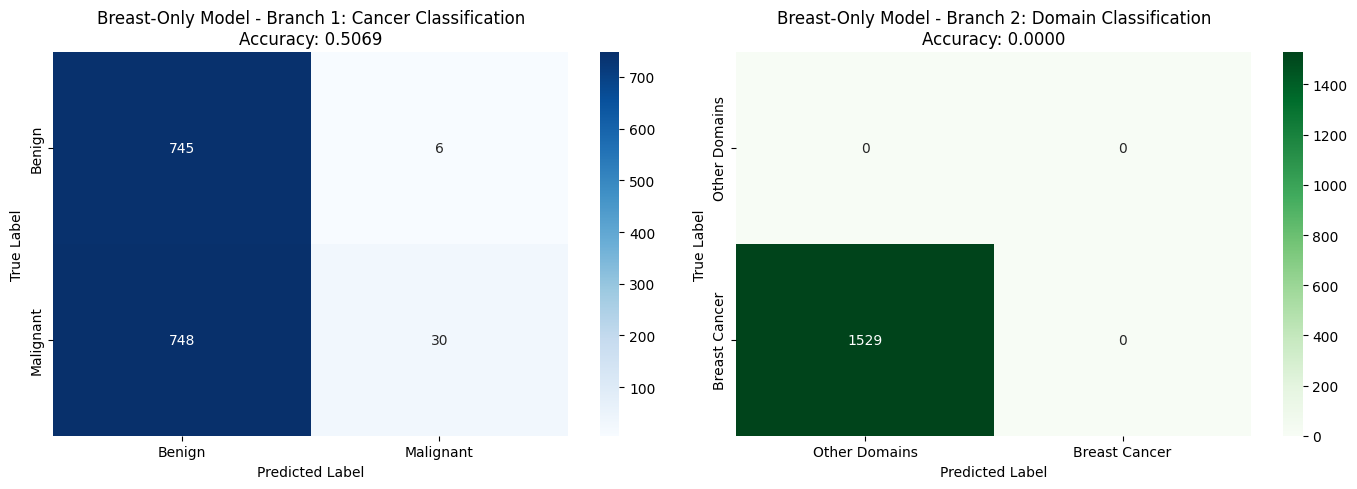

In [20]:
# Create confusion matrices for breast-only model
if 'breast_only_model' in locals():
    breast_only_cm1 = confusion_matrix(breast_only_all_labels1, breast_only_all_preds1, labels=[0, 1])
    breast_only_cm2 = confusion_matrix(breast_only_all_labels2, breast_only_all_preds2, labels=[0, 1])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Branch 1 confusion matrix
    sns.heatmap(breast_only_cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
               xticklabels=['Benign', 'Malignant'],
               yticklabels=['Benign', 'Malignant'])
    axes[0].set_title(f'Breast-Only Model - Branch 1: Cancer Classification\nAccuracy: {breast_only_acc1:.4f}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Branch 2 confusion matrix
    sns.heatmap(breast_only_cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
               xticklabels=['Other Domains', 'Breast Cancer'],
               yticklabels=['Other Domains', 'Breast Cancer'])
    axes[1].set_title(f'Breast-Only Model - Branch 2: Domain Classification\nAccuracy: {breast_only_acc2:.4f}')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('breast_only_model_confusion_matrices.png', dpi=150, bbox_inches='tight')
    print("✓ Confusion matrices saved to breast_only_model_confusion_matrices.png")
    plt.show()

In [21]:
# Classification reports for breast-only model
if 'breast_only_model' in locals():
    print("=" * 80)
    print("BREAST-ONLY MODEL - BRANCH 1: CANCER CLASSIFICATION")
    print("=" * 80)
    print(classification_report(breast_only_all_labels1, breast_only_all_preds1, 
                              target_names=['Benign', 'Malignant'],
                              digits=4, zero_division=0))
    
    print("\n" + "=" * 80)
    print("BREAST-ONLY MODEL - BRANCH 2: DOMAIN CLASSIFICATION")
    print("=" * 80)
    print(classification_report(breast_only_all_labels2, breast_only_all_preds2, 
                              target_names=['Other Domains', 'Breast Cancer'],
                              digits=4, zero_division=0))

BREAST-ONLY MODEL - BRANCH 1: CANCER CLASSIFICATION
              precision    recall  f1-score   support

      Benign     0.4990    0.9920    0.6640       751
   Malignant     0.8333    0.0386    0.0737       778

    accuracy                         0.5069      1529
   macro avg     0.6662    0.5153    0.3689      1529
weighted avg     0.6691    0.5069    0.3636      1529


BREAST-ONLY MODEL - BRANCH 2: DOMAIN CLASSIFICATION
               precision    recall  f1-score   support

Other Domains     0.0000    0.0000    0.0000       0.0
Breast Cancer     0.0000    0.0000    0.0000    1529.0

     accuracy                         0.0000    1529.0
    macro avg     0.0000    0.0000    0.0000    1529.0
 weighted avg     0.0000    0.0000    0.0000    1529.0



## Masking Test Interpretation